The project is based on five seasons of Premier League data in 5 CSVs


In [3]:
import pandas as pd

import glob
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score, roc_auc_score

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay


**STEP 1 : Combine 5 Season CSVs into One Dataset**



In [4]:
# Read all CSVs in a folder
files = glob.glob("/content/Football/*.csv")
df_list = [pd.read_csv(f) for f in files]

# Combine them
df = pd.concat(df_list, ignore_index=True)

# Save combined dataset
df.to_csv("combined_dataset.csv", index=False)
print("✅ Combined dataset saved as combined_dataset.csv")


✅ Combined dataset saved as combined_dataset.csv


**STEP 2: Clean the dataset and create target column (HomeWin)**


In [5]:
# Keep important columns
df_clean = df[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR']].copy()

# Convert Date into date format
df_clean['Date'] = pd.to_datetime(df_clean['Date'], dayfirst=True, errors='coerce')

# Create target column: HomeWin
df_clean['HomeWin'] = (df_clean['FTHG'] > df_clean['FTAG']).astype(int)

# Save cleaned dataset
df_clean.to_csv("cleaned_dataset.csv", index=False)
print("✅ Cleaned dataset saved as cleaned_dataset.csv")

print(df_clean.head())


✅ Cleaned dataset saved as cleaned_dataset.csv
        Date     HomeTeam     AwayTeam  FTHG  FTAG FTR  HomeWin
0 2025-08-15    Liverpool  Bournemouth     4     2   H        1
1 2025-08-16  Aston Villa    Newcastle     0     0   D        0
2 2025-08-16     Brighton       Fulham     1     1   D        0
3 2025-08-16   Sunderland     West Ham     3     0   H        1
4 2025-08-16    Tottenham      Burnley     3     0   H        1


**STEP 3: Create Team Statistics (Rolling Averages Before Each Match)**

In [6]:
# Create "home team table"
home = df_clean[['Date','HomeTeam','AwayTeam','FTHG','FTAG']].copy()
home.columns = ['Date','Team','Opponent','GoalsFor','GoalsAgainst']
home['Win'] = (home['GoalsFor'] > home['GoalsAgainst']).astype(int)

# Create "away team table"
away = df_clean[['Date','AwayTeam','HomeTeam','FTAG','FTHG']].copy()
away.columns = ['Date','Team','Opponent','GoalsFor','GoalsAgainst']
away['Win'] = (away['GoalsFor'] > away['GoalsAgainst']).astype(int)

# Combine
teams = pd.concat([home, away], ignore_index=True).sort_values(['Team','Date'])

# Cumulative stats (before match)
teams['cum_goals_for'] = teams.groupby('Team')['GoalsFor'].cumsum() - teams['GoalsFor']
teams['cum_goals_against'] = teams.groupby('Team')['GoalsAgainst'].cumsum() - teams['GoalsAgainst']
teams['cum_matches'] = teams.groupby('Team').cumcount()
teams['cum_wins'] = teams.groupby('Team')['Win'].cumsum() - teams['Win']

# Averages before match
teams['avg_goals_for_prev'] = teams['cum_goals_for'] / teams['cum_matches'].replace(0, pd.NA)
teams['avg_goals_against_prev'] = teams['cum_goals_against'] / teams['cum_matches'].replace(0, pd.NA)
teams['win_rate_prev'] = teams['cum_wins'] / teams['cum_matches'].replace(0, pd.NA)

# Merge back to main dataset
home_stats = teams[['Date','Team','avg_goals_for_prev','avg_goals_against_prev','win_rate_prev']]
home_stats.columns = ['Date','HomeTeam','home_avg_for','home_avg_against','home_winrate']

away_stats = teams[['Date','Team','avg_goals_for_prev','avg_goals_against_prev','win_rate_prev']]
away_stats.columns = ['Date','AwayTeam','away_avg_for','away_avg_against','away_winrate']

df_features = df_clean.merge(home_stats, on=['Date','HomeTeam'], how='left')
df_features = df_features.merge(away_stats, on=['Date','AwayTeam'], how='left')

# Save final dataset
df_features.to_csv("final_dataset.csv", index=False)
print("✅ Final dataset saved as final_dataset.csv")

print(df_features.head())


✅ Final dataset saved as final_dataset.csv
        Date     HomeTeam     AwayTeam  FTHG  FTAG FTR  HomeWin home_avg_for  \
0 2025-08-15    Liverpool  Bournemouth     4     2   H        1     2.243421   
1 2025-08-16  Aston Villa    Newcastle     0     0   D        0     1.559211   
2 2025-08-16     Brighton       Fulham     1     1   D        0     1.546053   
3 2025-08-16   Sunderland     West Ham     3     0   H        1         <NA>   
4 2025-08-16    Tottenham      Burnley     3     0   H        1     1.822368   

  home_avg_against home_winrate away_avg_for away_avg_against away_winrate  
0         1.019737     0.631579     1.307018         1.614035     0.342105  
1         1.394737     0.460526     1.743421         1.342105     0.460526  
2         1.434211     0.381579     1.438596         1.473684     0.377193  
3             <NA>         <NA>     1.368421         1.592105     0.342105  
4         1.506579     0.467105     0.986842         1.723684     0.157895  


**STEP 4: Feature Engineering - Creating Difference Metrics (Home vs Away)**

In [7]:
df_features['diff_avg_for'] = df_features['home_avg_for'] - df_features['away_avg_for']
df_features['diff_avg_against'] = df_features['home_avg_against'] - df_features['away_avg_against']
df_features['diff_winrate'] = df_features['home_winrate'] - df_features['away_winrate']

print(df_features[['Date','HomeTeam','AwayTeam','diff_avg_for','diff_avg_against','diff_winrate']].head())


        Date     HomeTeam     AwayTeam diff_avg_for diff_avg_against  \
0 2025-08-15    Liverpool  Bournemouth     0.936404        -0.594298   
1 2025-08-16  Aston Villa    Newcastle    -0.184211         0.052632   
2 2025-08-16     Brighton       Fulham     0.107456        -0.039474   
3 2025-08-16   Sunderland     West Ham         <NA>             <NA>   
4 2025-08-16    Tottenham      Burnley     0.835526        -0.217105   

  diff_winrate  
0     0.289474  
1          0.0  
2     0.004386  
3         <NA>  
4     0.309211  


**STEP 5: Data Preparation & Model Training**

In [8]:
# Drop rows with missing values
df_model = df_features.dropna(subset=['diff_avg_for','diff_avg_against','diff_winrate','HomeWin']).copy()

# Features and target
X = df_model[['diff_avg_for','diff_avg_against','diff_winrate']]
y = df_model['HomeWin']

# Split data into train/test sets
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df_model.index, test_size=0.2, random_state=42, stratify=y
)

# Create pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver='liblinear'))
])

# Train model on training set
pipe.fit(X_train, y_train)
print("Model training complete")


Model training complete


**STEP 6: Prediction & Evaluation**

In [9]:
# Predict on test set
y_proba = pipe.predict_proba(X_test)[:,1]
y_pred = (y_proba >= 0.5).astype(int)

# Evaluate performance
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Full dataset predictions
df_model['pred_prob_homewin'] = pipe.predict_proba(X)[:,1]
df_model['pred_homewin'] = (df_model['pred_prob_homewin'] >= 0.5).astype(int)

# Save full predictions
predictions_full = df_model[['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','HomeWin','pred_prob_homewin','pred_homewin']]
predictions_full.to_csv("predictions_full.csv", index=False)

# Save test set predictions
predictions_test = df_model.loc[idx_test, ['Date','HomeTeam','AwayTeam','FTHG','FTAG','FTR','HomeWin']].copy()
predictions_test['pred_prob_homewin'] = y_proba
predictions_test['pred_homewin'] = y_pred
predictions_test.to_csv("predictions.csv", index=False)

print("Predictions saved")
print(predictions_test.head())


Accuracy: 0.6286644951140065
ROC AUC: 0.6933264533883728
Predictions saved
           Date    HomeTeam  AwayTeam  FTHG  FTAG FTR  HomeWin  \
1168 2023-05-28  Man United    Fulham     2     1   H        1   
713  2022-04-09     Watford     Leeds     0     3   A        0   
43   2023-08-19      Wolves  Brighton     1     4   A        0   
542  2021-12-01     Watford   Chelsea     1     2   A        0   
350  2024-04-14    West Ham    Fulham     0     2   A        0   

      pred_prob_homewin  pred_homewin  
1168           0.481714             0  
713            0.454263             0  
43             0.354166             0  
542            0.123925             0  
350            0.430828             0  


**STEP 7: Calibration Table - Predicted vs Observed Home Win Probabilities**

In [10]:
# Load predictions
df = pd.read_csv("predictions_full.csv")

# Drop rows with missing data
df = df.dropna(subset=['pred_prob_homewin','HomeWin'])

# Create bins
bins = [i/10 for i in range(0,11)]  # 0.0,0.1,...1.0
df['bin'] = pd.cut(df['pred_prob_homewin'], bins=bins, include_lowest=True, right=False)

# Compute calibration table
cal = df.groupby('bin').agg(
    avg_pred=('pred_prob_homewin','mean'),
    observed=('HomeWin','mean'),
    count=('HomeWin','count')
).reset_index()

# Save to CSV
cal.to_csv("calibration.csv", index=False)
print("✅ calibration.csv saved")


✅ calibration.csv saved


/tmp/ipython-input-4116298486.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cal = df.groupby('bin').agg(


**STEP 8 : Model Evaluation - ROC Curve & Confusion Matrix**

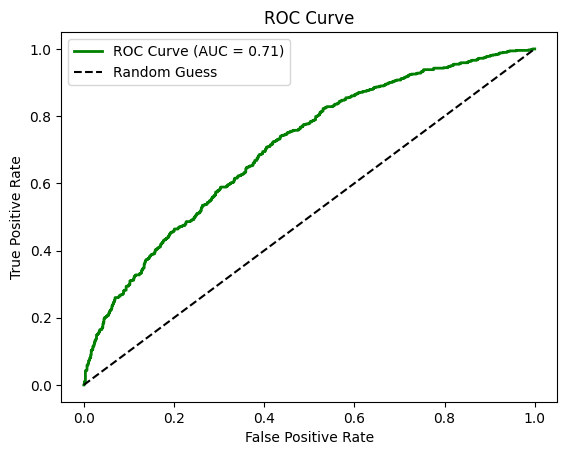

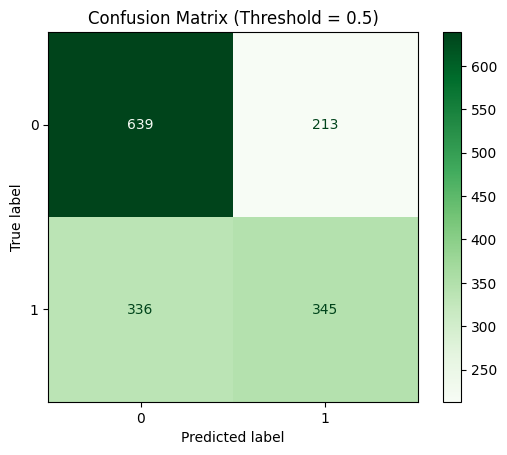

✅ Displayed & Saved: roc_curve.png (green) and confusion_matrix.png (green)


In [15]:


# Load predictions
df = pd.read_csv("predictions_full.csv")

# True values and predicted probabilities
y_true = df['HomeWin']
y_score = df['pred_prob_homewin']

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_true, y_score)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color="green", linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], 'k--', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.savefig("roc_curve.png", dpi=150)
plt.show()   # ✅ Show graph
plt.close()

# --- Confusion Matrix ---
y_pred = (y_score >= 0.5).astype(int)
cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Greens")   # Use green shades
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()   # ✅ Show graph
plt.close()

print("✅ Displayed & Saved: roc_curve.png (green) and confusion_matrix.png (green)")
